# **Perkenalan Dataset**

**Tentang Data**

---

*   Sumber Data kaggle.com
*   Sumber Data “Bank Transaction Dataset for Fraud Detection”
*.  Modif by Dicoding
*   Oleh Maziya Ats Tsaqofi
*   Tanggal 30 Mei 2026

# **1. Import Library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing

import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import joblib
from sklearn.decomposition import PCA
from google.colab import files
import os

# **2. Memuat Dataset**

In [2]:
# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

# Memuat Dataset dari drive
file_path = '/content/drive/My Drive/Colab Notebooks/DicodingProject/bank_transactions_data_edited.csv'
df = pd.read_csv(file_path)

df.head()
df.info()
df.columns.tolist()

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14

['TransactionID',
 'AccountID',
 'TransactionAmount',
 'TransactionDate',
 'TransactionType',
 'Location',
 'DeviceID',
 'IP Address',
 'MerchantID',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'PreviousTransactionDate']

In [3]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


**Metode yang Digunakan**

Exploratory Data Analysis (EDA) dilakukan menggunakan fungsi `head()`, `info()`, dan `describe()` untuk memahami struktur dataset.

**Alasan Penggunaan**

EDA diperlukan untuk mengetahui jumlah data, tipe data setiap fitur, serta karakteristik statistik dasar sebelum dilakukan proses preprocessing dan clustering.

**Hasil yang Didapat**

Dataset terdiri dari 2537 data transaksi dengan 16 fitur yang mencakup informasi transaksi, pelanggan, akun, dan perangkat. Dataset memiliki kombinasi fitur numerik dan kategorikal yang akan diproses lebih lanjut pada tahap preprocessing.


### Visualisasi (Target Skilled & Advanced)

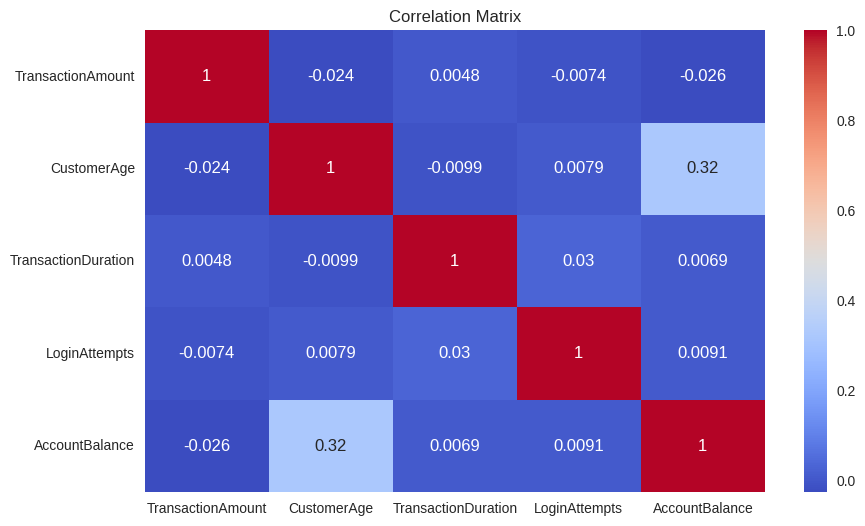

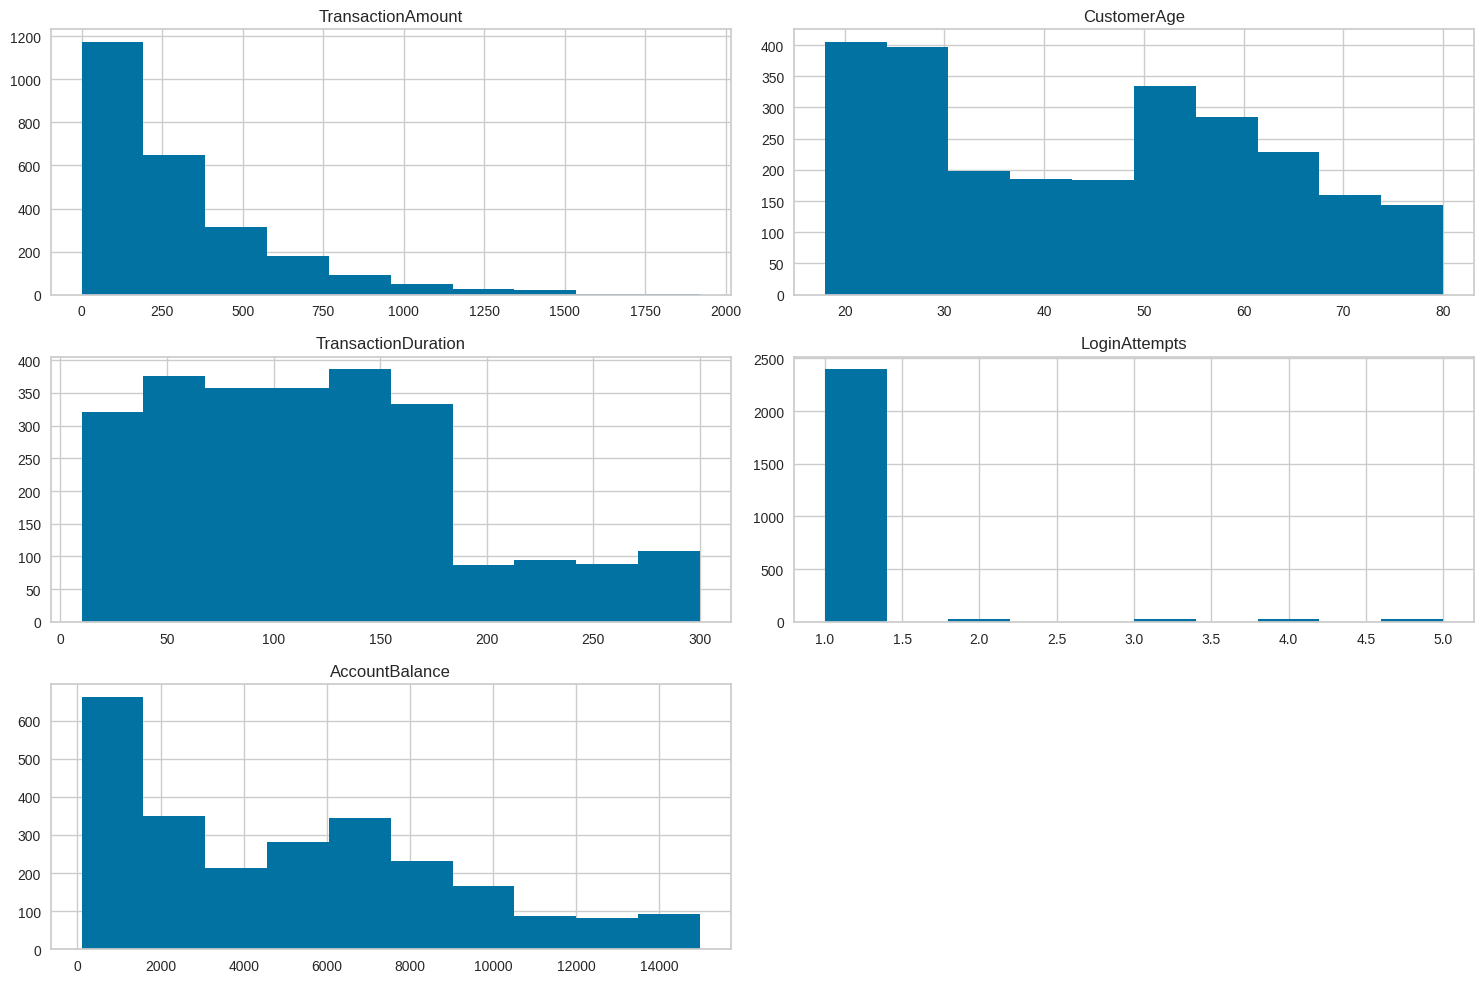

In [4]:
# Korelasi Fitur Numerik
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Matrix')
plt.show()

# Histogram Semua Fitur Numerik
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

# **3. Pembersihan dan Pra Pemrosesan**

In [5]:
# Cek Missing Value
df.isnull().sum()
print("Jumlah missing values sebelum perbaikan:")
print(df.isnull().sum())

df = df.dropna()
print("\nJumlah missing values setelah perbaikan")
print(df.isnull().sum())


Jumlah missing values sebelum perbaikan:
TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64

Jumlah missing values setelah perbaikan
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance     

In [6]:
# Cek Data Duplikat
df.duplicated().sum()
print('Jumlah data duplikat sebelum perbaikan:', df.duplicated().sum())

df = df.drop_duplicates()
print('Jumlah data duplikat setelah perbaikan:', df.duplicated().sum())

Jumlah data duplikat sebelum perbaikan: 21
Jumlah data duplikat setelah perbaikan: 0


In [7]:
drop_columns = [
    'TransactionID',
    'AccountID',
    'TransactionDate',
    'DeviceID',
    'IP Address',
    'MerchantID',
    'PreviousTransactionDate'
]

df = df.drop(columns=drop_columns, errors='ignore')

df.columns.tolist()

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

In [8]:
# Cek kolom Kategorikal
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

# Encoding labelencoder
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68


In [9]:
df.info()

df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
Index: 2135 entries, 0 to 2535
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionAmount    2135 non-null   float64
 1   TransactionType      2135 non-null   int64  
 2   Location             2135 non-null   int64  
 3   Channel              2135 non-null   int64  
 4   CustomerAge          2135 non-null   float64
 5   CustomerOccupation   2135 non-null   int64  
 6   TransactionDuration  2135 non-null   float64
 7   LoginAttempts        2135 non-null   float64
 8   AccountBalance       2135 non-null   float64
dtypes: float64(5), int64(4)
memory usage: 166.8 KB


['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

## Handling Outlier

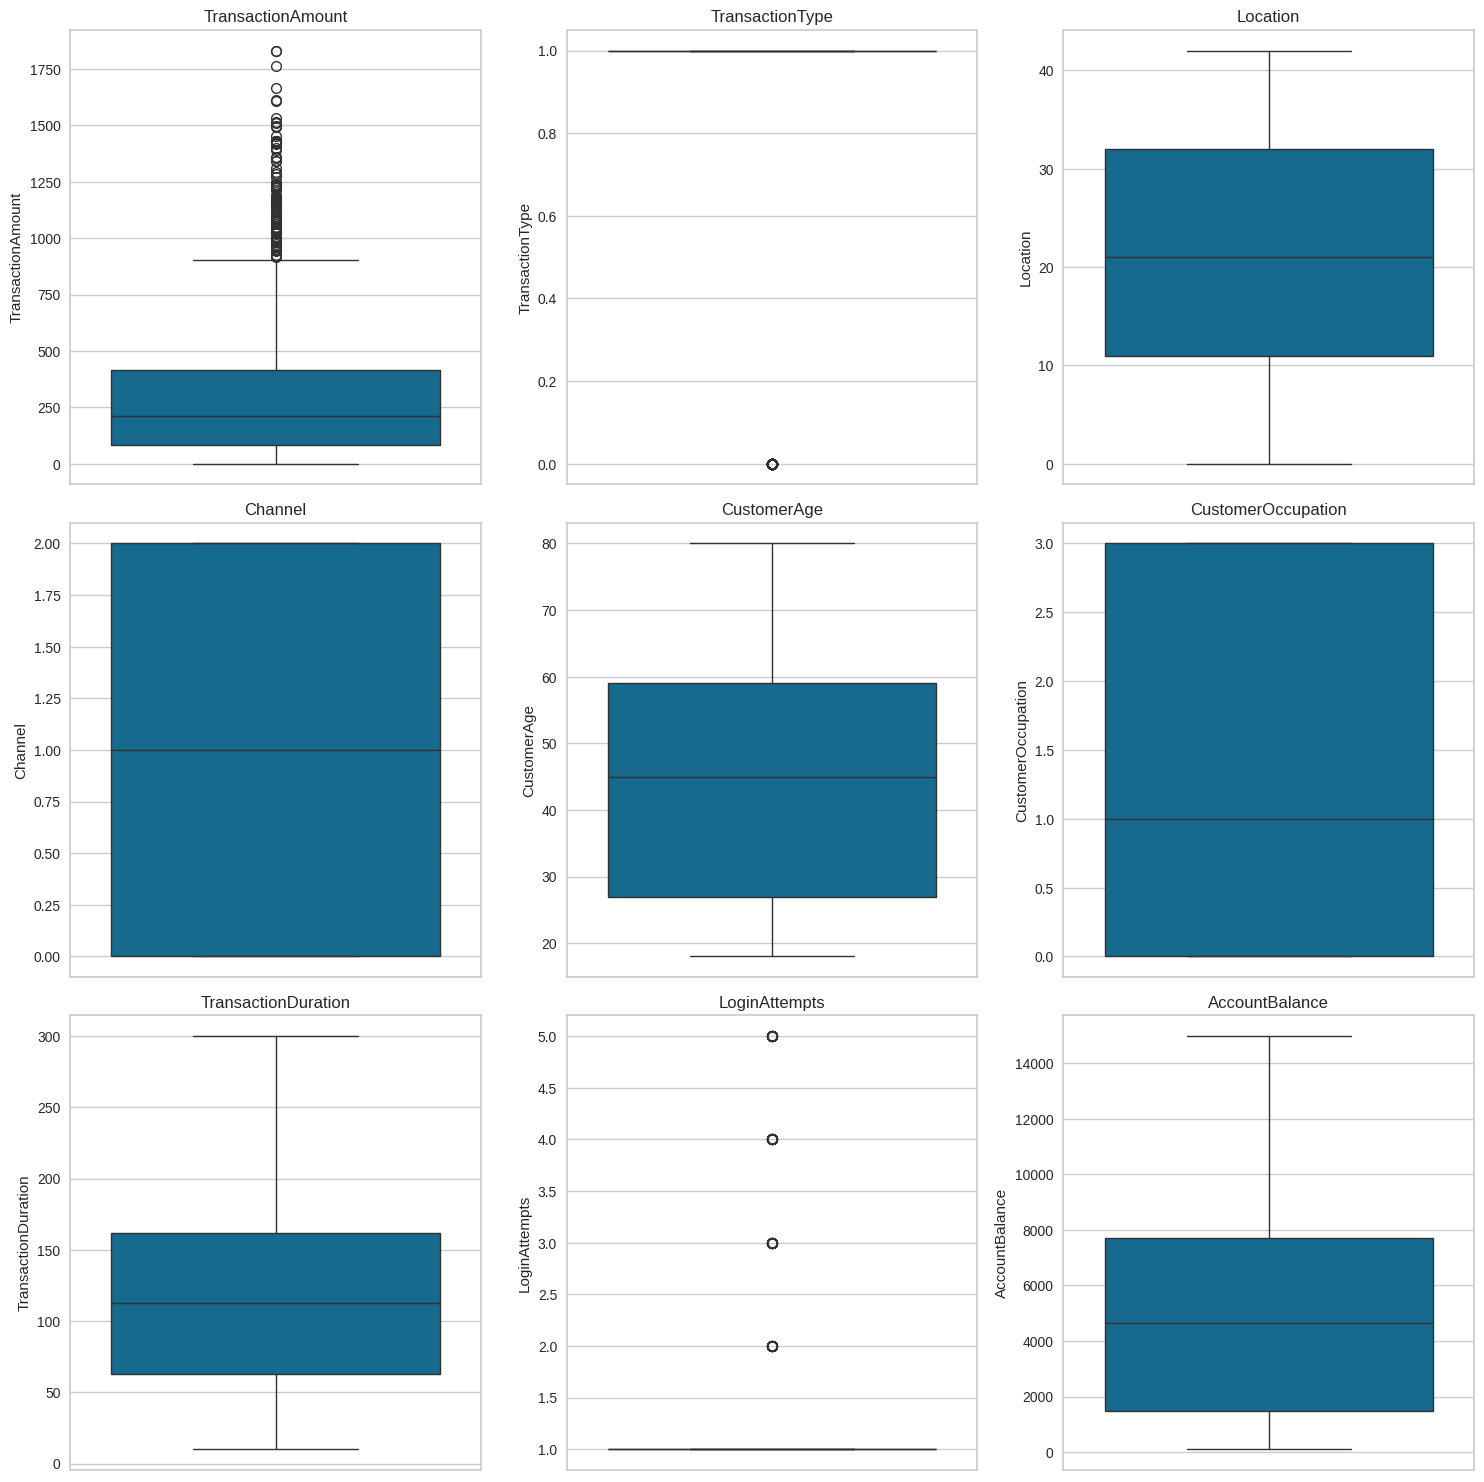

In [10]:
# Identifikasi Outlier
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [11]:
# Menghapus outlier dengan IQR
df_outlier = df.copy()

numeric_cols = df_outlier.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df_outlier[col].quantile(0.25)
    Q3 = df_outlier[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    df_outlier = df_outlier[
        (df_outlier[col] >= lower) &
        (df_outlier[col] <= upper)
    ]

print("Jumlah data sebelum:", len(df))
print("Jumlah data sesudah:", len(df_outlier))

Jumlah data sebelum: 2135
Jumlah data sesudah: 1501


In [12]:
print(df.shape)

(2135, 9)


## Feature Scalling

In [13]:
# Scalling
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(
    df_scaled,
    columns=df.columns
)

df_scaled.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-0.976321,0.541439,1.199032,-1.213199,1.423196,-1.323458,-0.552642,-0.203367,0.004753
1,0.268633,0.541439,-0.508295,-1.213199,1.311032,-1.323458,0.294261,-0.203367,2.211240
2,-0.590614,0.541439,0.142115,1.265442,-1.436987,1.318096,-0.905518,-0.203367,-1.013390
3,-0.390507,0.541439,0.955128,1.265442,-1.044413,1.318096,-1.343085,-0.203367,0.886881
4,-0.707976,0.541439,0.548622,-1.213199,-1.493069,1.318096,0.731827,-0.203367,-1.100323


In [14]:
df_scaled.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,2.135000e+03,2.135000e+03,2.135000e+03,2.135000e+03,2.135000e+03,2.135000e+03,2.135000e+03,2.135000e+03,2.135000e+03
mean,-2.246447e-16,7.030546e-17,-1.223065e-16,5.075305e-17,-1.676515e-16,9.984207e-18,-6.988945e-17,8.320173e-18,-8.153769e-17
std,1.000234e+00,1.000234e+00,1.000234e+00,1.000234e+00,1.000234e+00,1.000234e+00,1.000234e+00,1.000234e+00,1.000234e+00
min,-1.023864e+00,-1.846932e+00,-1.727814e+00,-1.213199e+00,-1.493069e+00,-1.323458e+00,-1.554811e+00,-2.033670e-01,-1.273714e+00
25%,-7.392758e-01,5.414385e-01,-8.335000e-01,-1.213199e+00,-9.883308e-01,-1.323458e+00,-8.067131e-01,-2.033670e-01,-9.215238e-01
50%,-2.913985e-01,5.414385e-01,-2.048716e-02,2.612150e-02,2.114568e-02,-4.429397e-01,-1.009606e-01,-2.033670e-01,-1.161626e-01
75%,4.006053e-01,5.414385e-01,8.738269e-01,1.265442e+00,8.062941e-01,1.318096e+00,5.906768e-01,-2.033670e-01,6.643260e-01
max,5.269692e+00,5.414385e-01,1.686840e+00,1.265442e+00,1.984017e+00,1.318096e+00,2.538554e+00,6.715972e+00,2.522328e+00


## Binning

In [15]:
df['Age_Bin'] = pd.cut(
    df['CustomerAge'],
    bins=[0, 30, 50, 100],
    labels=['Young', 'Adult', 'Senior']
)
df[['CustomerAge', 'Age_Bin']].head(10)

,CustomerAge,Age_Bin
0,70.0,Senior
1,68.0,Senior
2,19.0,Young
3,26.0,Young
5,18.0,Young
6,37.0,Adult
7,67.0,Senior
8,51.0,Senior
9,55.0,Senior
10,52.0,Senior


In [16]:
le_bin = LabelEncoder()
df['Age_Bin'] = le_bin.fit_transform(df['Age_Bin'])
df[['CustomerAge', 'Age_Bin']].head(10)

,CustomerAge,Age_Bin
0,70.0,1
1,68.0,1
2,19.0,2
3,26.0,2
5,18.0,2
6,37.0,0
7,67.0,1
8,51.0,1
9,55.0,1
10,52.0,1


# **4.Membangun Model Clustering**

In [17]:
df_scaled.shape

(2135, 9)

In [18]:
df_scaled.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-0.976321,0.541439,1.199032,-1.213199,1.423196,-1.323458,-0.552642,-0.203367,0.004753
1,0.268633,0.541439,-0.508295,-1.213199,1.311032,-1.323458,0.294261,-0.203367,2.211240
2,-0.590614,0.541439,0.142115,1.265442,-1.436987,1.318096,-0.905518,-0.203367,-1.013390
3,-0.390507,0.541439,0.955128,1.265442,-1.044413,1.318096,-1.343085,-0.203367,0.886881
4,-0.707976,0.541439,0.548622,-1.213199,-1.493069,1.318096,0.731827,-0.203367,-1.100323


## Elbow Methode

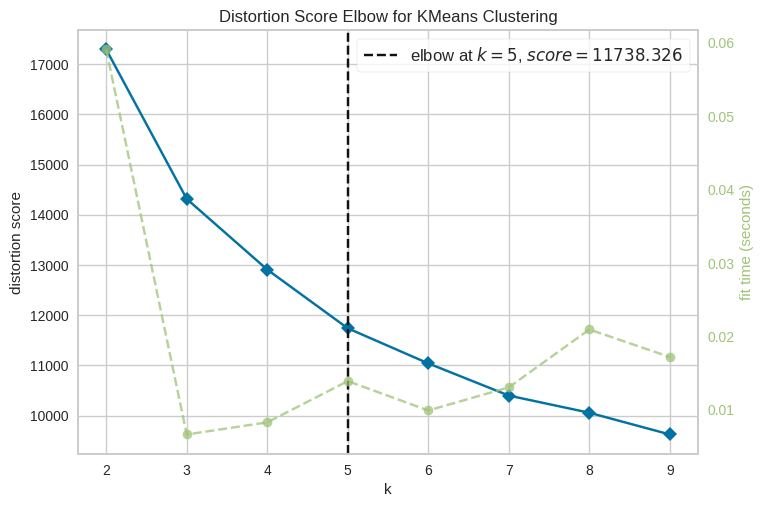

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
model = KMeans(random_state=42)

visualizer = KElbowVisualizer(
    model,
    k=(2,10)
)

visualizer.fit(df_scaled)
visualizer.show()

## K-Means Clustering

In [20]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(df_scaled)

# Label Clustering
df_scaled['Target'] = clusters

# Cek Hasil
df_scaled['Target'].value_counts()

,count
Target,
1,637
2,550
3,519
4,352
0,77


In [21]:
joblib.dump(
    kmeans,
    "model_clustering.h5"
)

['model_clustering.h5']

## Silhouette Score

In [22]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    df_scaled.drop('Target', axis=1),
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.16208576114620524


## PCA

In [23]:
# Menjalankan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(
    df_scaled.drop('Target', axis=1)
)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Target'] = clusters
pca_df.head()

,PC1,PC2,Target
0,-1.535586,1.225678,1
1,-2.768382,1.287986,3
2,2.119917,-0.508716,2
3,0.787907,-0.622020,2
4,2.189407,1.239704,2


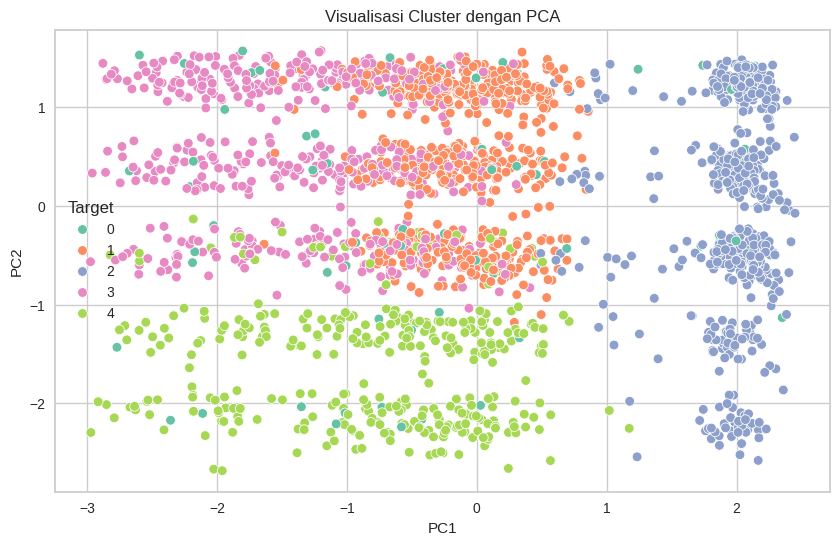

In [24]:
# Visualisasi PCA
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Target',
    palette='Set2'
)

plt.title('Visualisasi Cluster dengan PCA')
plt.show()

In [25]:
joblib.dump(
    pca,
    "PCA_model_clustering.h5"
)

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

In [26]:
df['Target'] = clusters
cluster_summary = df.groupby('Target').agg(['mean', 'min', 'max'])
cluster_summary

TransactionAmount                TransactionType           Location  \
                    mean   min      max            mean min max       mean   
Target                                                                       
0             279.489091  1.93  1531.31        0.766234   0   1  20.532468   
1             294.901931  0.84  1830.00        1.000000   1   1  20.896389   
2             323.380909  0.26  1762.28        0.792727   0   1  21.421818   
3             278.906031  0.32  1607.55        1.000000   1   1  21.705202   
4             296.734148  2.03  1831.02        0.000000   0   0  21.119318   

                 Channel  ... TransactionDuration LoginAttempts            \
       min max      mean  ...                 max          mean  min  max   
Target                    ...                                               
0        0  42  1.064935  ...               291.0      3.948052  3.0  5.0   
1        0  42  0.846154  ...               300.0      1.009419  1.0  2.0   
2        0  42  0.989091  ...               299.0      1.010909  1.0  2.0   
3        0  42  0.892100  ...               300.0      1.015414  1.0  2.0   
4        0  42  1.312500  ...               294.0      1.011364  1.0  2.0   

       AccountBalance                      Age_Bin          
                 mean      min       max      mean min max  
Target                                                      
0         5452.108701   271.78  14851.28  1.012987   0   2  
1         3904.117284   112.76   7996.70  0.802198   0   2  
2         1508.368327   102.20   9963.39  1.996364   0   2  
3         9316.171580  4401.78  14977.99  0.651252   0   2  
4         6543.666705   184.72  14935.50  0.724432   0   2  

[5 rows x 30 columns]

In [27]:
pd.set_option('display.max_columns', None)
cluster_summary

TransactionAmount                TransactionType           Location  \
                    mean   min      max            mean min max       mean   
Target                                                                       
0             279.489091  1.93  1531.31        0.766234   0   1  20.532468   
1             294.901931  0.84  1830.00        1.000000   1   1  20.896389   
2             323.380909  0.26  1762.28        0.792727   0   1  21.421818   
3             278.906031  0.32  1607.55        1.000000   1   1  21.705202   
4             296.734148  2.03  1831.02        0.000000   0   0  21.119318   

                 Channel         CustomerAge             CustomerOccupation  \
       min max      mean min max        mean   min   max               mean   
Target                                                                        
0        0  42  1.064935   0   2   43.857143  18.0  80.0           1.363636   
1        0  42  0.846154   0   2   57.742543  26.0  80.0           1.470958   
2        0  42  0.989091   0   2   23.172727  18.0  33.0           2.970909   
3        0  42  0.892100   0   2   45.605010  26.0  70.0           0.341040   
4        0  42  1.312500   0   2   53.116477  26.0  80.0           1.011364   

               TransactionDuration              LoginAttempts            \
       min max                mean   min    max          mean  min  max   
Target                                                                    
0        0   3          134.389610  11.0  291.0      3.948052  3.0  5.0   
1        0   2          117.094192  10.0  300.0      1.009419  1.0  2.0   
2        1   3          120.707273  11.0  299.0      1.010909  1.0  2.0   
3        0   1          122.724470  10.0  300.0      1.015414  1.0  2.0   
4        0   3          117.914773  10.0  294.0      1.011364  1.0  2.0   

       AccountBalance                      Age_Bin          
                 mean      min       max      mean min max  
Target                                                      
0         5452.108701   271.78  14851.28  1.012987   0   2  
1         3904.117284   112.76   7996.70  0.802198   0   2  
2         1508.368327   102.20   9963.39  1.996364   0   2  
3         9316.171580  4401.78  14977.99  0.651252   0   2  
4         6543.666705   184.72  14935.50  0.724432   0   2

# **6. Mengeksport Data**

In [28]:
df.to_csv('data_clustering.csv', index=False)

os.listdir()

['.config',
 'data_clustering.csv',
 'model_clustering.h5',
 'PCA_model_clustering.h5',
 'drive',
 'sample_data']

In [29]:
files.download('data_clustering.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>